# Flux sweeping in the pi-flux kagome Dirac spin liquid

This notebook implements part of the example workflow from the [TeMFpy paper](https://arxiv.org/abs/2510.05227), which considers a $\pi$-flux kagome model on a shifted cylinder with a spin flux $\theta$ threaded through it.
Specifically, we compute the inverse correlation length spectrum of its Gutzwiller-projected iMPS ground state at half filling for a single value of $\theta$.
To achieve this, the notebook is structured into the following steps:

1. Construct the Hamiltonians
2. Build the correlation matrices
3. Obtain the iMPS representation and project to spin space
4. Compute the inverse correlation lengths

The full version of the code, used to generate all figures in paper, can be found in the [TeMFpy projects repository](https://github.com/temfpy/projects/tree/main/pi_flux_kagome).

<p style="font-size:2em"><strong>1. Construct the Hamiltonians</strong></p>

The Hamiltonian of the $\pi$-flux kagome model is given by

$$
\hat{H}_{\pi\text{-flux}}(\theta) = - \sum_\sigma \sum_{\langle ij \rangle} e^{i\varphi_{ij}} f^\dagger_{i,\sigma} f_{j,\sigma}\, e^{\sigma\theta[\mathrm{cell}(i)-\mathrm{cell}(j)]/2L_2} \equiv \sum_\sigma \sum_{\alpha\beta} f^\dagger_{\alpha,\sigma}\, [h_\sigma(\theta)]_{\alpha\beta}\, f_{\beta,\sigma} \, ,
$$

where $\mathrm{cell}(i)$ denotes the unit cell of the lattice containing site $i$.
Since the Hamiltonian is block diagonal in spin space and $h_\downarrow(\theta)=\bigl(h_\uparrow(\theta)\bigr)^*$, we only need to construct $h_\uparrow(\theta)$.

**Specifying all hoppings** - To build a quadratic Hamiltonian, a good first step is to specify the hoppings of the model.
Due to translation invariance, we only need to specify the hoppings for a single unit cell.
A hopping is given by an amplitude, the origin of the hopping, and the translation to the target.
Since a lattice site can be specified by its unit-cell coordinates $(x,y)$ and its basis index $u$, we distinguish two types of hoppings:
- intra-hopping: a hopping within the same unit cell,
- inter-hopping: a hopping between two unit cells.
In the following, the unit-cell coordinates are expressed in terms of the primitive basis vectors $a_1$ and $a_2$.

In [20]:
import numpy as np

def get_intra_hoppings(t):
    """
    Format: u: [(t,ut), ...]
    u = index of the basis site of the origin
    t = hopping amplitude
    ut = index of the basis site of the target
    """
    return {
         0: [(t, 1), (-t, 2)],
         1: [(-t, 2)],
         2: [(t, 3)],
         3: [(-t, 4), (-t, 5)],
         4: [(t, 5)],
    }

def get_inter_hoppings(t, flux):
    """
    Format: u: [(t,[ut, delta_a]), ...]
    u = index of the basis site of the origin
    t = hopping amplitude
    ut = index of the basis site of the target
    delta_a = translation vector connecting the unit cells of the origin and the target
    """
    phase = np.exp(-1j * flux)
    return {
        1: [(t, [0, np.array([1,0])])],
        2: [(t, [4, np.array([-1,0])])],
        4: [(t, [3, np.array([1,0])])],
        5: [(t*phase, [0, np.array([0,1])]), (t*phase, [1, np.array([-1,1])])]
    }

**Apply hoppings** - Next, we need to be able to apply a hopping, i.e., given a position and a translation, determine the target site.
To do so, we need to check:

- (1) Is the target within the lattice?
- (2) What is the position of the target?

Together, these two checks implement the boundary conditions of the shifted cylinder.

In [21]:
def translate(pos, translation, L1, L2):
    x,y, _ = pos
    ut, delta_a = translation
    target = [(x+delta_a[0]), (y+delta_a[1]), ut]

    if target[1] < 0 or target[1] >= L2:
        target[0] = target[0] + np.sign(target[1])
        target[1] = target[1] % L2

    if target[0] < 0 or target[0] >= L1:
        return None
    else:
        return target

**Assembling the Hamiltonian** - With the hoppings specified, we now need to convert a position into a 1D index. 
We choose a snake-like numbering (standard for MPS). Then, the Hamiltonian is built by looping over all unit cells, applying all hoppings each time.
We need two cylinders whose lengths differ by the desired iMPS unit cell and which are long enough for the iMPS unit cell extracted from the middle of the cylinder to be representative of the thermodynamic limit.

In [22]:
def get_index(pos, L2):
    p1,p2,u = pos
    return 6 * (p2 + L2 * p1) + u

def generate_sp_hamiltonian(L1, L2, spinflux):
    t = -1.0
    H = np.zeros((6*L1*L2, 6*L1*L2), dtype=complex)

    intra_hoppings = get_intra_hoppings(t)
    inter_hoppings = get_inter_hoppings(t, spinflux/(2*L2))

    for p1 in range(L1):
        for p2 in range(L2):
            for u in range(6):
                pos = [p1, p2, u]
                idx = get_index(pos, L2)

                # Intra-cell hoppings
                if u in intra_hoppings:
                    for hopping in intra_hoppings[u]:
                        t_hop, u_target = hopping
                        target_pos = [p1, p2, u_target]
                        target_idx = get_index(target_pos, L2)
                        H[idx, target_idx] += t_hop

                # Inter-cell hoppings
                if u in inter_hoppings:
                    for hopping in inter_hoppings[u]:
                        t_hop, translation = hopping
                        target_pos = translate(pos, translation, L1, L2)
                        if target_pos is not None:
                            target_idx = get_index(target_pos, L2)
                            H[idx, target_idx] += t_hop
    H = H + H.conj().T
    return H

L1, L2, spinflux = 50, 2, np.pi

H_long_up = generate_sp_hamiltonian(L1 +1, L2, spinflux)
H_short_up = H_long_up[:-6, :-6]

<p style="font-size:2em"><strong>2. Build the correlation matrices</strong></p>

Since the Hamiltonian is block diagonal in spin space, the spinful correlation matrix $C^{(\mathrm{spinful)}}(\theta)$, can be constructed from the up-spin correlation matrix $C_\uparrow(\theta)$.
Usually, this would be handled by `temfpy.slater.spinful_correlation_matrix()`. However here, $h_\uparrow(\theta)$ and $h_\downarrow(\theta)$ are not equal due to the spin-flux insertion, so we implement

$$
    \left[C^{(\mathrm{spinful)}}_{\mathrm{ph}}(\theta)\right]_{ij} =
    \begin{pmatrix}
        C_\uparrow(\theta)_{ij} & 0 \\
        0 &  \delta_{ij} - C_\downarrow(\theta)_{ij}
    \end{pmatrix} =
    \begin{pmatrix}
        C_\uparrow(\theta)_{ij} & 0 \\
        0 &  \delta_{ij} - C_\uparrow(\theta)^*_{ij}
    \end{pmatrix} \, ,
$$

which also performs a particle-hole rotation on the down spins so that the $U(1)$ particle number corresponds to $S^z$.


In [23]:
from temfpy.slater import correlation_matrix

def spinful_C_with_conjugation(H):
    L = len(H)
    assert L%2 == 0 # otherwise half-filling is impossible

    C_up, _= correlation_matrix(H, L//2)
    # Add down-spin part
    C = np.zeros((2*L, 2*L), dtype=C_up.dtype)
    C[::2, ::2] = C_up
    C[1::2, 1::2] = np.eye(L) - C_up.conj()
    return C

C_short_spinful = spinful_C_with_conjugation(H_short_up)
C_long_spinful = spinful_C_with_conjugation(H_long_up)

<p style="font-size:2em"><strong>3. Obtain the iMPS representation and project to spin space</strong></p>

With the two spinful correlation matrices, we can use `temfpy.slater.C_to_iMPS()` to obtain the iMPS representation of the ground state at half filling and `temfpy.gutzwiller.abrikosov_ph()` to project it into spin space.
For this, we have to specify which unit cell of the longer mean-field state should be extracted as a representative of the thermodynamic limit: 
This unit cell should align with the repeating unit cell of the mean-field Hamiltonian (in our case, it should start and end at integer multiples of the $2\times6=12$-site unit cell) and be as close to the middle of the finite cylinders as possible.

In [24]:
from temfpy.slater import C_to_iMPS
from temfpy.gutzwiller import abrikosov_ph

idx_cut = 12 * ((L1 * L2 - 1) // 2) # Start of middle unit cell in C_short
psi_parton, err = C_to_iMPS(
    C_short = C_short_spinful, 
    C_long = C_long_spinful, 
    trunc_par = {'chi_max': 2000}, 
    sites_per_cell = 12, 
    cut = idx_cut,
)

# Gutzwiller projection
psi_spin = abrikosov_ph(psi_parton, inplace=False, return_canonical=True)

/home/simon/ownCloud_UZH/phd/Projects/MPStoiMPS/temfpy/src/temfpy/testing.py:88: ComparisonWarning: 
vL and vR do not SVD C_LR
Not equal to tolerance rtol=0, atol=1e-08

Mismatched elements: 2729 / 366912 (0.744%)
First 5 mismatches are at indices:
 [0, 110]: (-0.0038184542633444736+0.0011563413015452015j) (ACTUAL), (-0.003818444743847038+0.0011563482366750656j) (DESIRED)
 [0, 138]: (0.0038614384058592347+0.0010905950656880312j) (ACTUAL), (0.0038614297303503535+0.0010905897627798843j) (DESIRED)
 [1, 111]: (0.003818454177698147+0.0011563422239419291j) (ACTUAL), (0.003818444743847038+0.0011563482366750656j) (DESIRED)
 [416, 32]: (-0.00020693135276290872-0.0018346668097080454j) (ACTUAL), (-0.00020692085771839867-0.0018346713615569918j) (DESIRED)
 [416, 34]: (0.0007064020916684368-0.001329926307714506j) (ACTUAL), (0.0007064099769545193-0.0013299335608867515j) (DESIRED)
Max absolute difference among violations: 4.65259325e-08
Max relative difference among violations: 0.0001519
  warnings.wa

<p style="font-size:2em"><strong>4. Compute the inverse correlation lengths</strong></p>

We are interested in the correlation lengths of the spin-spin correlator $\langle S_i^+ S_j^-\rangle$, which can be obtained from the eigenvalues $\lambda$ of the iMPS transfer matrix via $\xi^{-1} = -\log|\lambda|$.
Since these operators change the conserved quantum number $2S^z$ of the iMPS, the relevant eigenvalues are those associated with eigenvectors of charge sector 2. We use [TeNpy](https://tenpy.readthedocs.io/en/latest/) for this.

In [25]:
from tenpy.networks import TransferMatrix

tm = TransferMatrix(psi_spin, psi_spin, charge_sector=[2])
num_ev = 20
eigV, _ = tm.eigenvectors(num_ev = num_ev)
inverse_correlation_length = -np.log(np.abs(eigV))

At this point, we have successfully computed the inverse correlation length for a single spin flux $\theta$.
To obtain the full spectrum, we would need to iterate over all values of the spin flux.
This, together with the code to obtain all other figures in the paper, can be found in the [examples repository](https://github.com/temfpy/temfpy).
As a last step in this notebook, we plot the correlation length for this single flux, and see that we indeed hit a Dirac cone ($\xi \rightarrow 0$) at $\theta = \pi$.

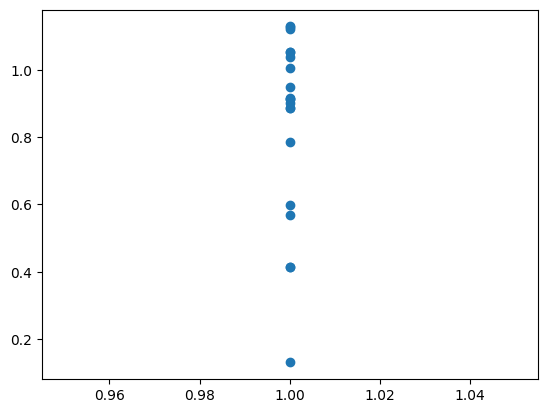

In [26]:
import matplotlib.pyplot as plt

fluxes = num_ev * [spinflux / np.pi]
plt.scatter(fluxes, inverse_correlation_length)